<h2>Stock Market Price Prediction</h2>

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = yf.download("ITC.NS",
                 start="2015-01-01",
                 end="2026-08-19",
                 auto_adjust=False)
df.columns = df.columns.droplevel(1)

[*********************100%***********************]  1 of 1 completed


In [3]:
print(df)

Price        Adj Close       Close        High         Low        Open  \
Date                                                                     
2015-01-01  156.948029  235.689560  236.812958  234.951324  235.978424   
2015-01-02  157.439682  236.427795  237.615387  235.753754  235.753754   
2015-01-05  158.059479  237.358612  238.674591  235.946335  236.684570   
2015-01-06  153.998459  231.260147  237.133926  230.457718  236.652466   
2015-01-07  151.134354  226.959122  233.667435  226.606049  229.173828   
...                ...         ...         ...         ...         ...   
2026-08-12  276.149994  276.149994  279.549988  275.399994  279.000000   
2026-08-13  278.500000  278.500000  278.500000  276.049988  276.200012   
2026-08-14  278.200012  278.200012  278.350006  275.950012  278.350006   
2026-08-17  273.049988  273.049988  278.200012  273.000000  278.200012   
2026-08-18  270.000000  270.000000  273.649994  269.149994  273.049988   

Price         Volume  
Date          

<h2>Week 1 EDA Questions & Dataset Analysis</h2>

<h5>1) What is the total number of rows and columns?</h5>

In [4]:
print("Number of Rows = ", df.shape[0])
print("Number of Columns = ",df.shape[1])

Number of Rows =  2874
Number of Columns =  6


<h5>2) What are the names of all the columns?</h5>

In [5]:
df.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

<h5>3) Display first 5 rows of the dataset.</h5>

In [6]:
df.head(5)

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-01,156.948029,235.689560,236.812958,234.951324,235.978424,2636761
2015-01-02,157.439682,236.427795,237.615387,235.753754,235.753754,6853849
2015-01-05,158.059479,237.358612,238.674591,235.946335,236.684570,8556295
2015-01-06,153.998459,231.260147,237.133926,230.457718,236.652466,13597291
2015-01-07,151.134354,226.959122,233.667435,226.606049,229.173828,12421217


<h5>4) What is the datatype of each column?</h5>

In [7]:
df.dtypes

Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

<h5>5) Are there any missing values in the dataset?</h5>

In [8]:
df.isnull().sum()

Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

<h5>6) Are there any duplicate rows in the dataset?</h5>

In [9]:
df.duplicated().sum()

np.int64(0)

<h5>7) What is the statistical summary of the numerical column?</h5>

In [10]:
df.describe()

Price,Adj Close,Close,High,Low,Open,Volume
count,2874.000000,2874.000000,2874.000000,2874.000000,2874.000000,2.874000e+03
mean,236.758235,288.621911,291.565124,285.949938,288.939128,1.665598e+07
std,97.877475,87.922248,88.440398,87.496873,88.001204,1.626309e+07
min,104.390198,141.789276,146.363113,129.608398,142.511459,0.000000e+00
25%,161.677208,218.176537,221.350140,215.464321,218.786377,8.803800e+06
50%,190.524910,262.755493,264.849838,260.035263,262.586990,1.239167e+07
75%,317.617249,355.696434,360.928230,346.788498,356.360298,1.917652e+07
max,463.949219,503.363953,508.900696,500.956665,501.293671,4.318516e+08


<h5>8) What is the data range covered by the dataset?</h5>

In [11]:
date_index = df.index
print("Range of dataset: ", date_index[0], " - ", date_index[-1])

Range of dataset:  2015-01-01 00:00:00  -  2026-08-18 00:00:00


<h5>9) What is highest closing price recorded in the dataset?</h5>

In [12]:
df['Close'].max()

503.36395263671875

<h5>10) On which date was the highest closing price recorded?</h5>

In [13]:
df[df['Close'] == df['Close'].max()]

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2024-09-26,463.949219,503.363953,504.326874,497.827179,498.453064,16086557


<h5>11) Which day had the lowest closing price?</h5>

In [14]:
df[df['Close'] == df['Close'].min()]

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2020-03-16,104.390198,141.789276,152.236893,139.863434,152.14061,34535653


<h5>12) What is the average closing price of the stock?</h5>

In [15]:
df['Close'].mean()

np.float64(288.6219108119638)

<h5>13) What is the median closing price?</h5>

In [16]:
df['Close'].median()

262.7554931640625

<h5>14) What is the standard deviation of the closing price?</h5>

In [17]:
df['Close'].std()

87.92224771574016

<h5>15) What is the variance of the closing price?</h5>

In [18]:
df['Close'].var()

7730.321643387974

<h5>16) Which day had the highest trading volume?</h5>

In [19]:
df[df['Volume'] == df['Volume'].max()]

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2025-05-28,400.659119,420.200012,422.600006,413.0,417.700012,431851622


<h5>17) How has the closing price changed over time?</h5>

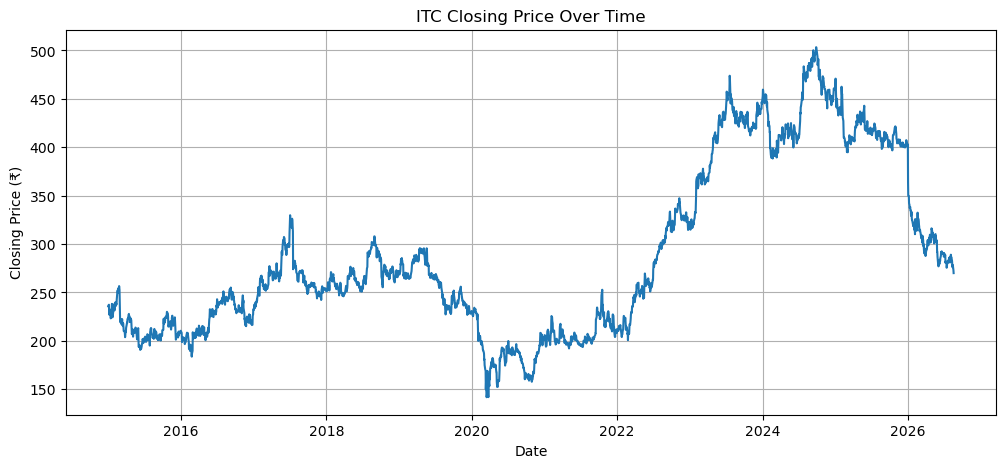

In [20]:
x = df.index
y = df['Close']

plt.figure(figsize=(12,5))
plt.plot(x, y)

plt.title("ITC Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price (₹)")

plt.grid(True)

plt.show()

<h5>18) How has the trading volume changed over time?</h5>

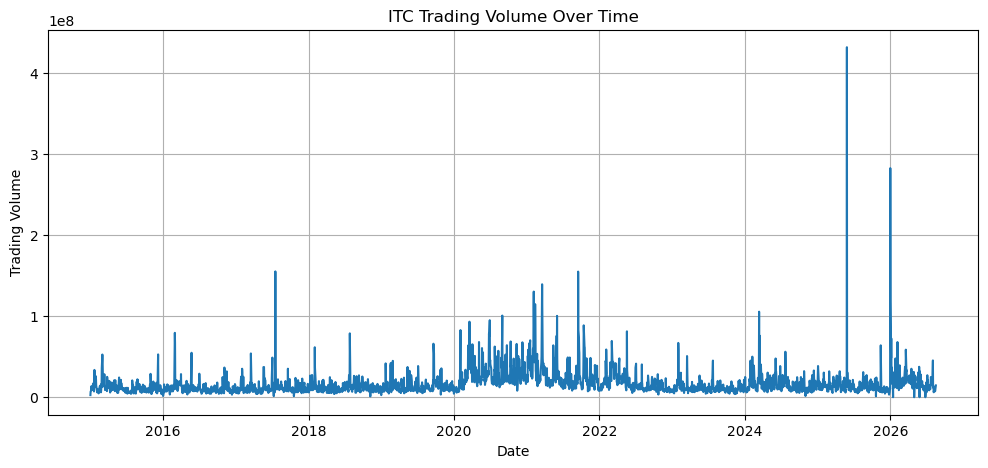

In [21]:
x = df.index
y = df['Volume']

plt.figure(figsize=(12,5))
plt.plot(x, y)

plt.title("ITC Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Trading Volume")

plt.grid(True)

plt.show()

<h5>19) What is the relationship between Opening Price and Closing Price?</h5>

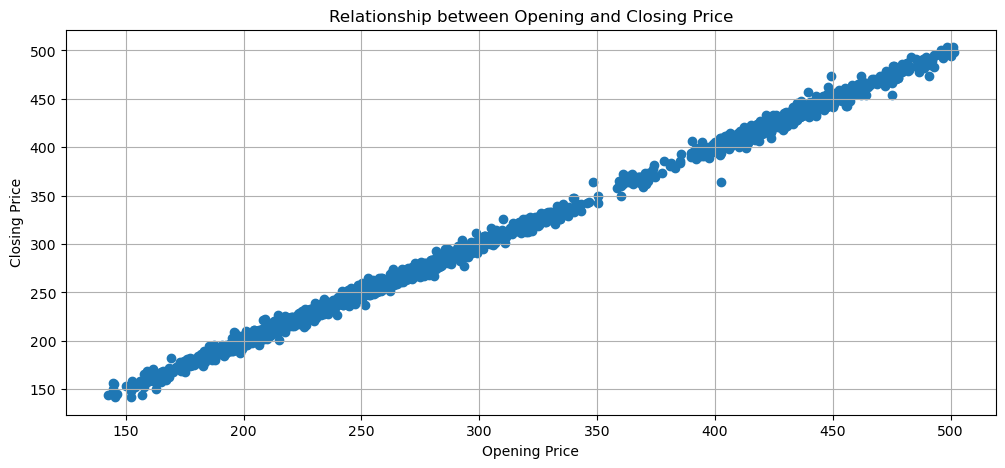

In [22]:
x = df['Open']
y = df['Close']

plt.figure(figsize=(12,5))
plt.scatter(x, y)

plt.xlabel("Opening Price")
plt.ylabel("Closing Price")
plt.title("Relationship between Opening and Closing Price")

plt.grid(True)
plt.show()

<h5>20) What was the average daily price range?</h5>

In [23]:
(df['High'] - df['Low']).mean()

np.float64(5.615185864368245)

<h2>Week 2 Data Preprocessing</h2>

In [24]:
df.head(10)

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-01,156.948029,235.689560,236.812958,234.951324,235.978424,2636761
2015-01-02,157.439682,236.427795,237.615387,235.753754,235.753754,6853849
2015-01-05,158.059479,237.358612,238.674591,235.946335,236.684570,8556295
2015-01-06,153.998459,231.260147,237.133926,230.457718,236.652466,13597291
2015-01-07,151.134354,226.959122,233.667435,226.606049,229.173828,12421217
2015-01-08,154.917511,232.640320,233.250168,228.178818,228.178818,8774566
2015-01-09,152.566406,229.109634,234.855026,226.670242,233.089676,11224780
2015-01-12,152.972519,229.719482,231.966278,228.596085,229.462708,10249032
2015-01-13,153.934326,231.163849,232.190964,229.366409,230.072556,12071158


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2874 entries, 2015-01-01 to 2026-08-18
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  2874 non-null   float64
 1   Close      2874 non-null   float64
 2   High       2874 non-null   float64
 3   Low        2874 non-null   float64
 4   Open       2874 non-null   float64
 5   Volume     2874 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 157.2 KB


In [26]:
df.describe()

Price,Adj Close,Close,High,Low,Open,Volume
count,2874.000000,2874.000000,2874.000000,2874.000000,2874.000000,2.874000e+03
mean,236.758235,288.621911,291.565124,285.949938,288.939128,1.665598e+07
std,97.877475,87.922248,88.440398,87.496873,88.001204,1.626309e+07
min,104.390198,141.789276,146.363113,129.608398,142.511459,0.000000e+00
25%,161.677208,218.176537,221.350140,215.464321,218.786377,8.803800e+06
50%,190.524910,262.755493,264.849838,260.035263,262.586990,1.239167e+07
75%,317.617249,355.696434,360.928230,346.788498,356.360298,1.917652e+07
max,463.949219,503.363953,508.900696,500.956665,501.293671,4.318516e+08


In [27]:
df.shape

(2874, 6)

In [28]:
df.isnull().sum()

Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df.index

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-05', '2015-01-06',
               '2015-01-07', '2015-01-08', '2015-01-09', '2015-01-12',
               '2015-01-13', '2015-01-14',
               ...
               '2026-08-05', '2026-08-06', '2026-08-07', '2026-08-10',
               '2026-08-11', '2026-08-12', '2026-08-13', '2026-08-14',
               '2026-08-17', '2026-08-18'],
              dtype='datetime64[ns]', name='Date', length=2874, freq=None)

In [31]:
df = df.sort_index()
df

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-01,156.948029,235.689560,236.812958,234.951324,235.978424,2636761
2015-01-02,157.439682,236.427795,237.615387,235.753754,235.753754,6853849
2015-01-05,158.059479,237.358612,238.674591,235.946335,236.684570,8556295
2015-01-06,153.998459,231.260147,237.133926,230.457718,236.652466,13597291
2015-01-07,151.134354,226.959122,233.667435,226.606049,229.173828,12421217
...,...,...,...,...,...,...
2026-08-12,276.149994,276.149994,279.549988,275.399994,279.000000,12630816
2026-08-13,278.500000,278.500000,278.500000,276.049988,276.200012,11335590
2026-08-14,278.200012,278.200012,278.350006,275.950012,278.350006,7338537


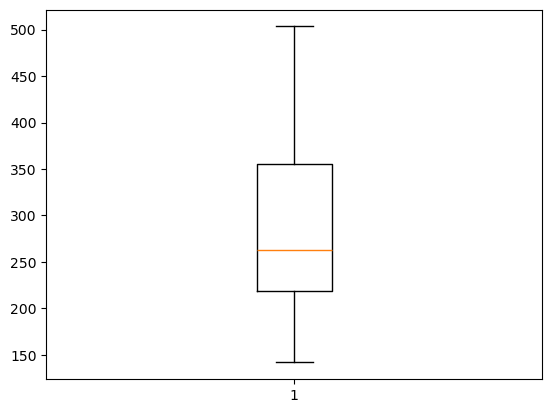

In [32]:
plt.boxplot(df['Close'])
plt.show()

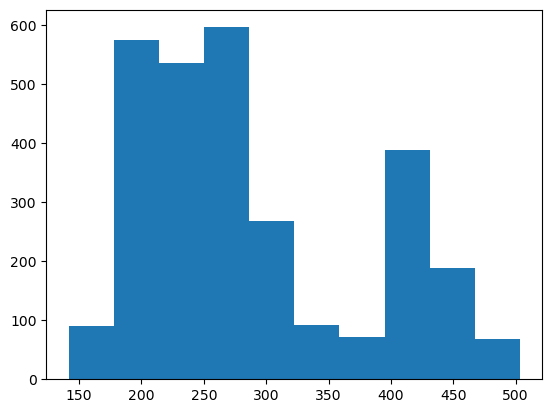

In [33]:
plt.hist(df['Close'])
plt.show()

<h3>Week 3 - Model Selection and Implementation</h3>

In [34]:
import warnings
warnings.filterwarnings('ignore')

In [35]:
df["Target"] = df["Close"].shift(-1)
df = df.dropna()
X = df[["Open", "High", "Low", "Volume"]]
y = df["Target"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, shuffle=False
)

In [37]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
test_prediction = model.predict(X_test)
print(test_prediction)

[326.38969655 330.84083216 335.04627694 333.21343122 334.32527043
 331.62650979 332.43702321 332.96414113 334.02742272 335.09867697
 341.15034715 342.98553261 340.5553389  338.51490457 345.9259141
 342.12954874 342.73590594 335.89460641 328.25774848 330.09271511
 332.19573913 328.20289731 323.11846374 326.03937188 325.28560329
 326.99460882 325.98087223 327.12897876 330.68866858 328.67546128
 324.79325553 325.29022287 322.83050776 324.26271686 326.2939655
 326.42535826 327.34185793 329.37407102 330.63922234 331.81730256
 327.4397857  320.96304678 327.0274948  324.98715941 323.11037696
 319.74561135 314.75125481 320.00230469 319.13041771 320.51849814
 320.31519884 319.78260332 319.48656388 319.03408234 315.13117027
 319.68492935 322.69400522 326.66977736 321.15987578 319.14336363
 316.63509601 316.42195566 316.8546535  319.15525553 321.81454763
 320.50628011 319.62343553 322.39751797 326.77287844 324.68619105
 333.98178195 333.63324231 336.28061705 333.02634019 365.81365375
 360.0996195

In [39]:
print(y_test)

Date
2022-10-18    333.505707
2022-10-19    336.731476
2022-10-20    332.783508
2022-10-21    334.805634
2022-10-24    333.457550
                 ...    
2026-08-11    276.149994
2026-08-12    278.500000
2026-08-13    278.200012
2026-08-14    273.049988
2026-08-17    270.000000
Name: Target, Length: 949, dtype: float64


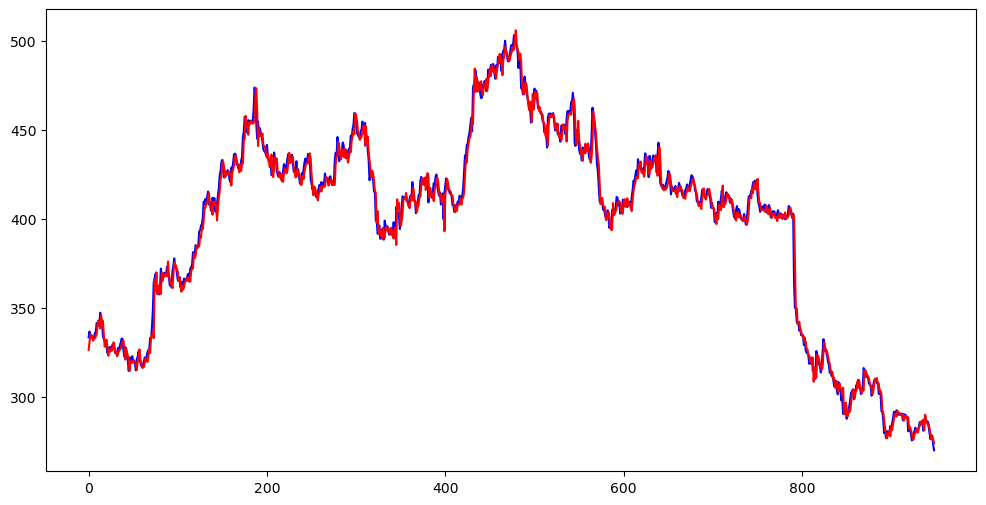

In [40]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual Price", color="blue")
plt.plot(test_prediction, label="Predicted Price", color="red")

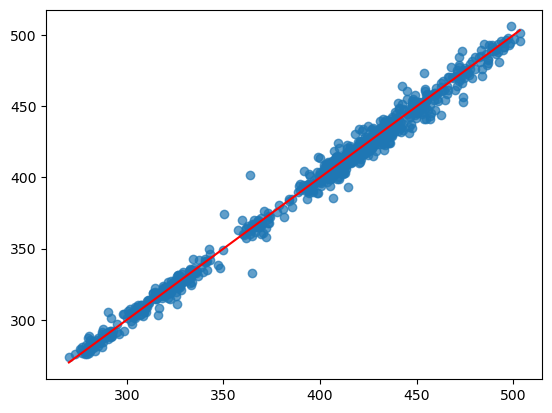

In [41]:
plt.scatter(y_test, test_prediction, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

In [42]:
df.tail(2)

Price,Adj Close,Close,High,Low,Open,Volume,Target
Date,,,,,,,
2026-08-14,278.200012,278.200012,278.350006,275.950012,278.350006,7338537,273.049988
2026-08-17,273.049988,273.049988,278.200012,273.000000,278.200012,12795275,270.000000


In [43]:
today_open = 278.350006
today_high = 278.350006
today_low = 275.950012
today_volume = 7338537

In [44]:
tomorrow_prediction = model.predict([[today_open, today_high, today_low, today_volume]])

In [45]:
print("Today's Open Price:", today_open)
print("Tomorrow's Predicted Close Price:", round(tomorrow_prediction[0], 2))

Today's Open Price: 278.350006
Tomorrow's Predicted Close Price: 276.0


In [46]:
print("Tomorrow's Actual Close Price:", df['Close'].tail(1).values) 

Tomorrow's Actual Close Price: [273.04998779]


In [47]:
model.score(X_test, y_test)

0.9912477532992914

In [48]:
from sklearn.metrics import mean_absolute_error

print("R²:", model.score(X_test, y_test))
print("MAE:", mean_absolute_error(y_test, test_prediction))

R²: 0.9912477532992914
MAE: 3.702688006495039


<h2>Manual Implementation</h2>

In [49]:
import numpy as np

In [50]:
X_train_manual = X_train.values
X_test_manual = X_test.values

y_train_manual = y_train.values
y_test_manual = y_test.values

In [51]:
X_train_bias = np.c_[
    np.ones(X_train_manual.shape[0]),
    X_train_manual
]

X_test_bias = np.c_[
    np.ones(X_test_manual.shape[0]),
    X_test_manual
]

In [52]:
manual_coefficients = np.linalg.inv(
    X_train_bias.T @ X_train_bias
) @ X_train_bias.T @ y_train_manual


In [53]:
manual_intercept = manual_coefficients[0]
manual_weights = manual_coefficients[1:]

print("Manual Intercept:", manual_intercept)
print("Manual Coefficients:", manual_weights)

Manual Intercept: 0.7848382626947661
Manual Coefficients: [-5.94428494e-01  8.53787652e-01  7.35484849e-01  8.51022160e-09]


In [54]:
test_prediction_manual = X_test_bias @ manual_coefficients

print("Manual Predictions:")
print(test_prediction_manual)

Manual Predictions:
[326.38969655 330.84083216 335.04627694 333.21343122 334.32527043
 331.62650979 332.43702321 332.96414113 334.02742272 335.09867697
 341.15034715 342.98553261 340.5553389  338.51490458 345.9259141
 342.12954874 342.73590594 335.89460641 328.25774848 330.09271511
 332.19573913 328.20289731 323.11846375 326.03937188 325.28560329
 326.99460882 325.98087223 327.12897876 330.68866858 328.67546128
 324.79325553 325.29022287 322.83050776 324.26271686 326.2939655
 326.42535827 327.34185793 329.37407102 330.63922234 331.81730256
 327.4397857  320.96304678 327.0274948  324.98715941 323.11037696
 319.74561135 314.75125481 320.00230469 319.13041771 320.51849814
 320.31519884 319.78260332 319.48656388 319.03408234 315.13117027
 319.68492935 322.69400522 326.66977736 321.15987579 319.14336363
 316.63509601 316.42195566 316.8546535  319.15525553 321.81454763
 320.50628011 319.62343553 322.39751797 326.77287844 324.68619105
 333.98178195 333.63324231 336.28061705 333.02634018 365.8

In [55]:
manual_mae = np.mean(
    np.abs(y_test_manual - test_prediction_manual)
)

print("Manual MAE:", manual_mae)

Manual MAE: 3.7026880063474676


In [56]:
ss_res_manual = np.sum(
    (y_test_manual - test_prediction_manual) ** 2
)

ss_tot_manual = np.sum(
    (y_test_manual - np.mean(y_test_manual)) ** 2
)

manual_r2 = 1 - (ss_res_manual / ss_tot_manual)

print("Manual R²:", manual_r2)

Manual R²: 0.991247753300094


In [57]:
print("\n--- COMPARISON ---")

print("Sklearn R²:", model.score(X_test, y_test))
print("Manual R²:", manual_r2)

print("Sklearn MAE:", mean_absolute_error(y_test, test_prediction))
print("Manual MAE:", manual_mae)


--- COMPARISON ---
Sklearn R²: 0.9912477532992914
Manual R²: 0.991247753300094
Sklearn MAE: 3.702688006495039
Manual MAE: 3.7026880063474676


In [58]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Random Forest - Bagging
model_bagging = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_bagging.fit(X_train, y_train)

prediction_bagging = model_bagging.predict(X_test)

# Evaluation
r2_bagging = r2_score(y_test, prediction_bagging)
mae_bagging = mean_absolute_error(y_test, prediction_bagging)

print("Random Forest (Bagging)")
print("R²:", r2_bagging)
print("MAE:", mae_bagging)

Random Forest (Bagging)
R²: -1.7678053716408049
MAE: 79.12789018862115


In [59]:
print("\n===== MODEL COMPARISON =====")

print("Linear Regression")
print("R² :", model.score(X_test, y_test))
print("MAE:", mean_absolute_error(y_test, test_prediction))

print("\nRandom Forest (Bagging)")
print("R² :", r2_bagging)
print("MAE:", mae_bagging)


===== MODEL COMPARISON =====
Linear Regression
R² : 0.9912477532992914
MAE: 3.702688006495039

Random Forest (Bagging)
R² : -1.7678053716408049
MAE: 79.12789018862115


In [60]:
import joblib

In [61]:
joblib.dump(model, 'tomorrow_close_predict.pkl')

['tomorrow_close_predict.pkl']

<h2>Multiple Model Comparison (Regression Only)</h2>
<p>In this section, we train and evaluate multiple standard regression algorithms on the exact same dataset and split. Each model is trained with the same simple pattern: define model &rarr; fit &rarr; predict &rarr; evaluate R² and MAE.</p>
<p><strong>Note on SVR:</strong> Notice that SVR produces a <em>negative R² score</em>. We explain below why this happens.</p>

In [62]:
# Model 1: Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)

r2_lr = r2_score(y_test, pred_lr)
mae_lr = mean_absolute_error(y_test, pred_lr)

print("Linear Regression")
print("R² Score:", round(r2_lr, 4))
print("MAE:", round(mae_lr, 2))

Linear Regression
R² Score: 0.9912
MAE: 3.7


In [63]:
# Model 2: Ridge Regression
from sklearn.linear_model import Ridge

model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)

pred_ridge = model_ridge.predict(X_test)

r2_ridge = r2_score(y_test, pred_ridge)
mae_ridge = mean_absolute_error(y_test, pred_ridge)

print("Ridge Regression")
print("R² Score:", round(r2_ridge, 4))
print("MAE:", round(mae_ridge, 2))

Ridge Regression
R² Score: 0.9912
MAE: 3.7


In [64]:
# Model 3: Lasso Regression
from sklearn.linear_model import Lasso

model_lasso = Lasso(alpha=0.1, max_iter=10000)
model_lasso.fit(X_train, y_train)

pred_lasso = model_lasso.predict(X_test)

r2_lasso = r2_score(y_test, pred_lasso)
mae_lasso = mean_absolute_error(y_test, pred_lasso)

print("Lasso Regression")
print("R² Score:", round(r2_lasso, 4))
print("MAE:", round(mae_lasso, 2))

Lasso Regression
R² Score: 0.9913
MAE: 3.7


In [65]:
# Model 4: ElasticNet Regression
from sklearn.linear_model import ElasticNet

model_en = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
model_en.fit(X_train, y_train)

pred_en = model_en.predict(X_test)

r2_en = r2_score(y_test, pred_en)
mae_en = mean_absolute_error(y_test, pred_en)

print("ElasticNet Regression")
print("R² Score:", round(r2_en, 4))
print("MAE:", round(mae_en, 2))

ElasticNet Regression
R² Score: 0.9913
MAE: 3.7


In [66]:
# Model 5: Support Vector Regressor (SVR) - Scaled
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# SVR is sensitive to feature scale, so scale X using only the training data.
scaler_svr = StandardScaler()
X_train_scaled = scaler_svr.fit_transform(X_train)
X_test_scaled = scaler_svr.transform(X_test)

model_svr = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
model_svr.fit(X_train_scaled, y_train)

pred_svr = model_svr.predict(X_test_scaled)

r2_svr = r2_score(y_test, pred_svr)
mae_svr = mean_absolute_error(y_test, pred_svr)

print("SVR (Support Vector Regressor - Scaled)")
print("R² Score:", round(r2_svr, 4))
print("MAE:", round(mae_svr, 2))


SVR (Support Vector Regressor - Scaled)
R² Score: -7.4983
MAE: 140.62


<h4>Why was the original SVR R² negative?</h4>
<p>The original SVR was trained without feature scaling. The <code>Volume</code> feature is measured in millions while price features are in hundreds, so the RBF kernel was strongly affected by the difference in scale.</p>
<p>The revised SVR uses <code>StandardScaler</code>, fitted only on <code>X_train</code>, and the test set is transformed using the same scaler. This prevents data leakage and gives SVR features comparable scales.</p>
<p><strong>Note:</strong> A negative R² is not an "accuracy" percentage. It means the model performed worse than the baseline that always predicts the mean of the test targets.</p>


In [67]:
# Model 6: Bagging (using Linear Regression as base estimator)
from sklearn.ensemble import BaggingRegressor

model_bagging = BaggingRegressor(
    estimator=LinearRegression(),
    n_estimators=50,
    random_state=42
)
model_bagging.fit(X_train, y_train)

pred_bagging = model_bagging.predict(X_test)

r2_bagging = r2_score(y_test, pred_bagging)
mae_bagging = mean_absolute_error(y_test, pred_bagging)

print("Bagging Regressor (Linear Regression)")
print("R² Score:", round(r2_bagging, 4))
print("MAE:", round(mae_bagging, 2))

Bagging Regressor (Linear Regression)
R² Score: 0.9913
MAE: 3.68


In [68]:
# Final Model Comparison Table
print("=" * 62)
print(f"{'Model':<30} {'R² Score':>12} {'MAE (₹)':>12}")
print("=" * 62)
print(f"{'Linear Regression':<30} {r2_lr:>12.4f} {mae_lr:>12.2f}")
print(f"{'Ridge Regression':<30} {r2_ridge:>12.4f} {mae_ridge:>12.2f}")
print(f"{'Lasso Regression':<30} {r2_lasso:>12.4f} {mae_lasso:>12.2f}")
print(f"{'ElasticNet':<30} {r2_en:>12.4f} {mae_en:>12.2f}")
print(f"{'SVR (Scaled)':<30} {r2_svr:>12.4f} {mae_svr:>12.2f}")
print(f"{'Bagging (Linear Regression)':<30} {r2_bagging:>12.4f} {mae_bagging:>12.2f}")
print("=" * 62)


Model                              R² Score      MAE (₹)
Linear Regression                    0.9912         3.70
Ridge Regression                     0.9912         3.70
Lasso Regression                     0.9913         3.70
ElasticNet                           0.9913         3.70
SVR (Scaled)                        -7.4983       140.62
Bagging (Linear Regression)          0.9913         3.68


<h3>Initial Model Comparison - Interpretation</h3>
<ul>
  <li>Linear Regression, Ridge, Lasso and ElasticNet provide baseline regression models.</li>
  <li>SVR is evaluated after feature scaling because distance-based/kernel models are sensitive to feature magnitude.</li>
  <li>Random Forest/Bagging provides a tree-based ensemble comparison.</li>
  <li>The final model choice should be based on the validation results from the Cross-Validation and Hyperparameter Tuning section below, not only on one test split.</li>
</ul>


<h2>Week 4 - Advanced Model Training, Cross-Validation & Hyperparameter Tuning</h2>
<p><strong>Important:</strong> Because this is stock-price time-series data, ordinary random K-Fold Cross-Validation is not appropriate. We use <code>TimeSeriesSplit</code> so every validation fold occurs after its corresponding training data. This reduces future-data leakage.</p>


<h3>1. Preprocessing Review</h3>
<p>The dataset contains only numerical predictors: Open, High, Low and Volume. Therefore categorical encoding is not required. Earlier EDA found no missing values and no duplicate rows.</p>
<p>For outliers, extreme stock prices can represent genuine market movements and should not automatically be deleted. Volume has a strong right-skew, so <code>log1p(Volume)</code> is used in the advanced modeling dataset to reduce the influence of very large volume values.</p>


In [69]:
# Advanced modeling dataset
import numpy as np
import pandas as pd

X_adv = df[["Open", "High", "Low", "Volume"]].copy()
y_adv = df["Target"].copy()

# Handle strong volume skew without deleting genuine observations
X_adv["Volume"] = np.log1p(X_adv["Volume"])

print("Missing values after preprocessing:")
print(X_adv.isnull().sum())

print("\nDuplicate rows in predictors:", X_adv.duplicated().sum())
print("\nAdvanced feature summary:")
display(X_adv.describe())


Missing values after preprocessing:
Price
Open      0
High      0
Low       0
Volume    0
dtype: int64

Duplicate rows in predictors: 0

Advanced feature summary:


Price,Open,High,Low,Volume
count,2873.000000,2873.000000,2873.000000,2873.000000
mean,288.944658,291.571360,285.955786,16.391090
std,88.016024,88.455162,87.511543,0.860965
min,142.511459,146.363113,129.608398,0.000000
25%,218.774338,221.342117,215.452286,15.990565
50%,262.538849,264.801697,259.987122,16.332079
75%,358.397064,361.237640,347.034668,16.769369
max,501.293671,508.900696,500.956665,19.883593


<h3>2. Outlier Identification using IQR</h3>
<p>The IQR rule identifies unusually distant observations. We report them rather than blindly deleting them, because financial extremes can be valid observations. The log transformation above is used to reduce the impact of extreme Volume values.</p>


In [70]:
# IQR-based outlier report
def iqr_outlier_report(data):
    report = []
    for col in data.columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = ((data[col] < lower) | (data[col] > upper)).sum()
        report.append([col, q1, q3, lower, upper, int(count)])
    return pd.DataFrame(
        report,
        columns=["Feature", "Q1", "Q3", "Lower Bound", "Upper Bound", "Outlier Count"]
    )

outlier_report = iqr_outlier_report(X_adv)
display(outlier_report)


,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count
0,Open,218.774338,358.397064,9.340248,567.831154,0
1,High,221.342117,361.237640,11.498833,571.080925,0
2,Low,215.452286,347.034668,18.078712,544.408241,0
3,Volume,15.990565,16.769369,14.822361,17.937573,62


<h3>3. Time-Series Cross-Validation</h3>
<p>Cross-Validation checks whether a model is stable across multiple historical validation windows. <code>TimeSeriesSplit</code> is used instead of random K-Fold because future observations must not be used to train a model that is being evaluated on the past.</p>


In [71]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Keep the final test set untouched until the end.
split_index = int(len(X_adv) * 0.67)

X_adv_train = X_adv.iloc[:split_index].copy()
X_adv_test = X_adv.iloc[split_index:].copy()
y_adv_train = y_adv.iloc[:split_index].copy()
y_adv_test = y_adv.iloc[split_index:].copy()

# TimeSeriesSplit is applied only to the training portion.
tscv = TimeSeriesSplit(n_splits=5)

cv_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1))
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

cv_results = []

for name, estimator in cv_models.items():
    scores = cross_validate(
        estimator,
        X_adv_train,
        y_adv_train,
        cv=tscv,
        scoring={"R2": "r2", "MAE": "neg_mean_absolute_error"},
        return_train_score=False,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV R²": scores["test_R2"].mean(),
        "Std CV R²": scores["test_R2"].std(),
        "Mean CV MAE": -scores["test_MAE"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    "Mean CV R²", ascending=False
).reset_index(drop=True)

display(cv_results_df.round(4))


,Model,Mean CV R²,Std CV R²,Mean CV MAE
0,Linear Regression,0.9641,0.0198,2.9852
1,Ridge,0.9640,0.0196,3.0063
2,Random Forest,0.8165,0.2233,5.6746
3,Gradient Boosting,0.7985,0.2426,5.8502
4,SVR,0.5254,0.7214,7.6023


<h3>4. Hyperparameter Tuning</h3>
<p>Hyperparameter tuning searches for parameter combinations that improve validation performance. <code>GridSearchCV</code> is combined with <code>TimeSeriesSplit</code> so the search remains time-series aware.</p>


In [72]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning uses ONLY the training portion.
# Scaling stays inside the Pipeline, so it is refitted safely within each CV fold.

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf"))
])

svr_params = {
    "model__C": [1, 10, 100],
    "model__epsilon": [0.01, 0.1, 0.2],
    "model__gamma": ["scale", 0.01, 0.1]
}

svr_grid = GridSearchCV(
    svr_pipeline,
    svr_params,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

svr_grid.fit(X_adv_train, y_adv_train)

print("Best SVR parameters:", svr_grid.best_params_)
print("Best SVR CV R²:", round(svr_grid.best_score_, 4))


Best SVR parameters: {'model__C': 100, 'model__epsilon': 0.1, 'model__gamma': 0.01}
Best SVR CV R²: 0.888


In [73]:
# Random Forest hyperparameter tuning
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_adv_train, y_adv_train)

print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best Random Forest CV R²:", round(rf_grid.best_score_, 4))


Best Random Forest parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best Random Forest CV R²: 0.8237


<h3>5. Final Time-Series Train/Test Evaluation of Tuned Models</h3>
<p>The chronological test set was separated before hyperparameter tuning and remains untouched during cross-validation and parameter search. The tuned models are refit on the training portion and evaluated only once on the later unseen test observations.</p>


In [74]:
# Refit the tuned models on the complete training portion only
best_svr = svr_grid.best_estimator_
best_svr.fit(X_adv_train, y_adv_train)

best_rf = RandomForestRegressor(
    **rf_grid.best_params_,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_adv_train, y_adv_train)

# Final evaluation on the untouched chronological test set
pred_svr_tuned = best_svr.predict(X_adv_test)
pred_rf_tuned = best_rf.predict(X_adv_test)

advanced_results = pd.DataFrame([
    {
        "Model": "Tuned SVR",
        "Train R²": best_svr.score(X_adv_train, y_adv_train),
        "Test R²": r2_score(y_adv_test, pred_svr_tuned),
        "Test MAE": mean_absolute_error(y_adv_test, pred_svr_tuned)
    },
    {
        "Model": "Tuned Random Forest",
        "Train R²": best_rf.score(X_adv_train, y_adv_train),
        "Test R²": r2_score(y_adv_test, pred_rf_tuned),
        "Test MAE": mean_absolute_error(y_adv_test, pred_rf_tuned)
    }
])

display(advanced_results.round(4))


,Model,Train R²,Test R²,Test MAE
0,Tuned SVR,0.9876,0.2142,39.1642
1,Tuned Random Forest,0.9958,-1.6899,77.8859


<h3>6. Overfitting / Underfitting Check</h3>
<p>A large difference between training R² and test R² can indicate overfitting. If both training and test scores are low, the model may be underfitting. These checks should be interpreted together with the cross-validation results.</p>


In [75]:
advanced_results["R² Gap"] = (
    advanced_results["Train R²"] - advanced_results["Test R²"]
)

display(advanced_results.round(4))


,Model,Train R²,Test R²,Test MAE,R² Gap
0,Tuned SVR,0.9876,0.2142,39.1642,0.7734
1,Tuned Random Forest,0.9958,-1.6899,77.8859,2.6857


<h3>7. Performance Visualizations</h3>
<p>The following graphs cover model comparison, actual-vs-predicted performance, residual behavior, and cross-validation stability.</p>


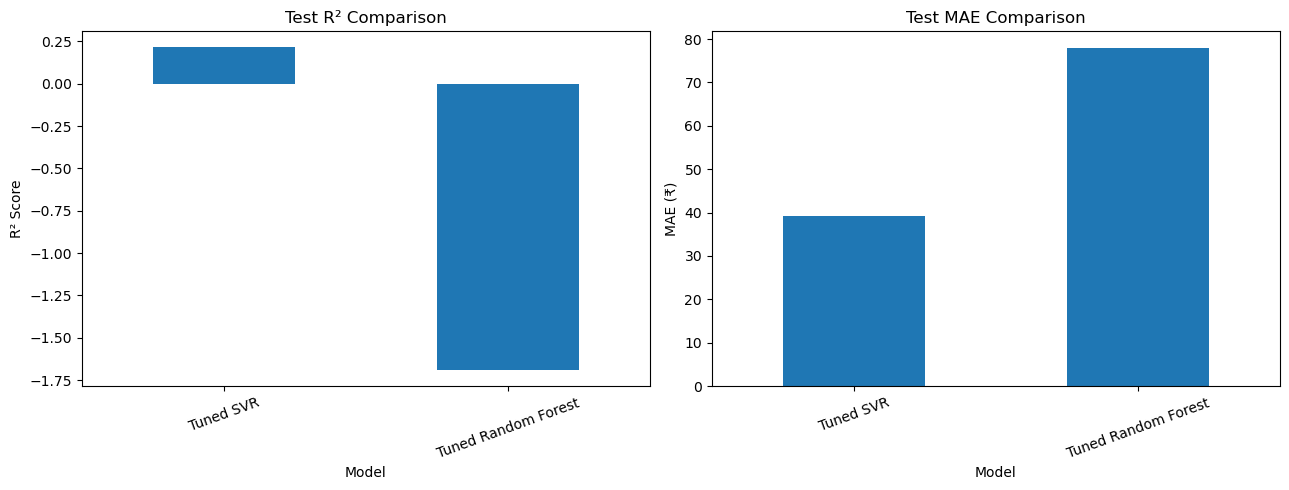

In [76]:
# Model performance comparison
plot_df = advanced_results.set_index("Model")[["Test R²", "Test MAE"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_df["Test R²"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Test R² Comparison")
axes[0].set_ylabel("R² Score")
axes[0].tick_params(axis="x", rotation=20)

plot_df["Test MAE"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Test MAE Comparison")
axes[1].set_ylabel("MAE (₹)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


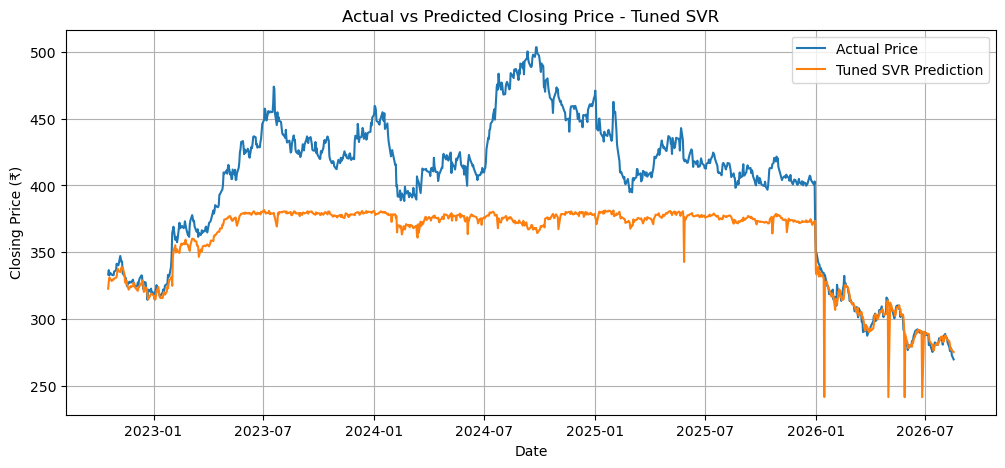

In [77]:
# Actual vs Predicted plot for tuned SVR
plt.figure(figsize=(12, 5))
plt.plot(y_adv_test.index, y_adv_test.values, label="Actual Price")
plt.plot(y_adv_test.index, pred_svr_tuned, label="Tuned SVR Prediction")
plt.title("Actual vs Predicted Closing Price - Tuned SVR")
plt.xlabel("Date")
plt.ylabel("Closing Price (₹)")
plt.legend()
plt.grid(True)
plt.show()


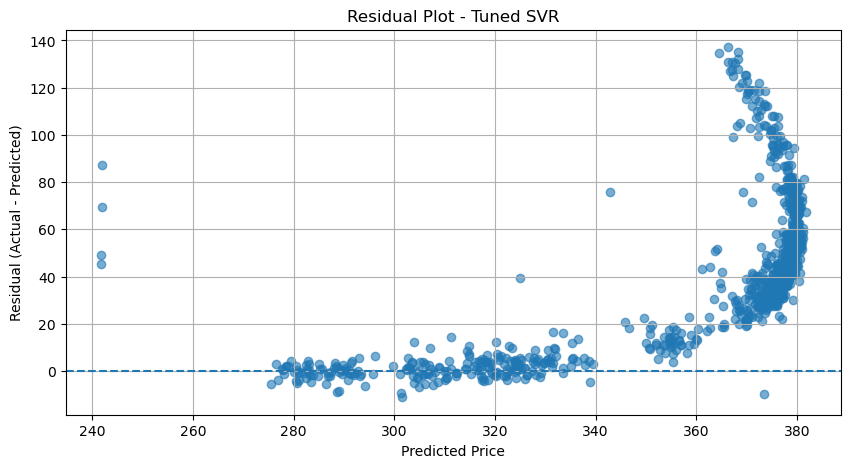

In [78]:
# Residual plot for tuned SVR
residuals = y_adv_test.values - pred_svr_tuned

plt.figure(figsize=(10, 5))
plt.scatter(pred_svr_tuned, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.title("Residual Plot - Tuned SVR")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(True)
plt.show()


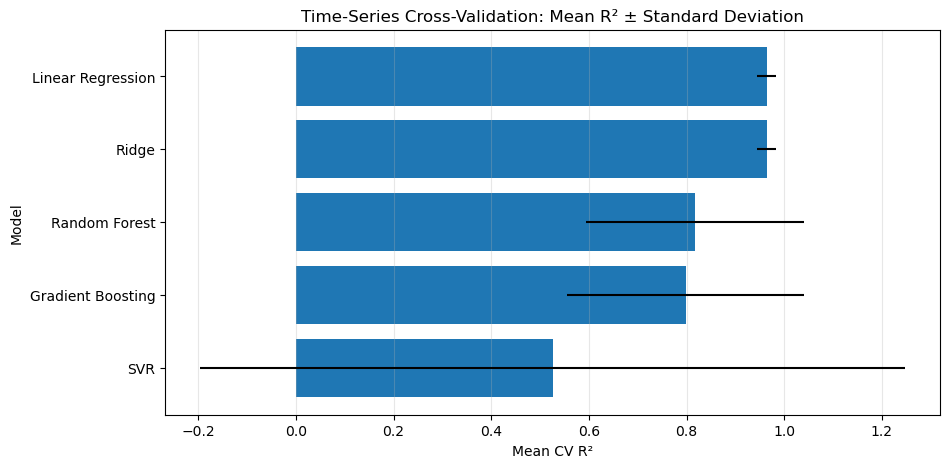

In [79]:
# Cross-validation stability plot for R²
cv_plot = cv_results_df.sort_values("Mean CV R²", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(cv_plot["Model"], cv_plot["Mean CV R²"], xerr=cv_plot["Std CV R²"])
plt.title("Time-Series Cross-Validation: Mean R² ± Standard Deviation")
plt.xlabel("Mean CV R²")
plt.ylabel("Model")
plt.grid(axis="x", alpha=0.3)
plt.show()


<h3>8. SOP Coverage Checklist</h3>
<ul>
<li><b>1. Problem Definition & Dataset Exploration:</b> Completed in Week 1.</li>
<li><b>2. Data Cleaning, Preprocessing & EDA:</b> Missing values, duplicates, data types, summary statistics, time ordering, boxplot, histogram and relationships are covered. Advanced preprocessing adds volume log transformation and IQR outlier reporting.</li>
<li><b>3. Model Creation:</b> Linear Regression, Ridge, Lasso, ElasticNet, scaled SVR and ensemble models are implemented. Linear Regression is also implemented manually using the normal equation.</li>
<li><b>4. Model Evaluation:</b> R² and MAE are calculated. Train/test comparison and residual analysis are added for advanced models.</li>
<li><b>5. Advanced Model Training:</b> Random Forest and Gradient Boosting are included, with Time-Series Cross-Validation and GridSearchCV hyperparameter tuning.</li>
<li><b>6. Visualization:</b> Time-series, volume, scatter, histogram, boxplot, actual-vs-predicted, residual and model-performance plots are included.</li>
<li><b>7. Flask Setup:</b> The notebook currently saves a model using Joblib. A Flask <code>app.py</code> and HTML form are still required as the application/deployment layer.</li>
<li><b>8. Front End:</b> A user-facing HTML form is still required for Flask input.</li>
<li><b>9. Backend & Deployment:</b> Flask request handling and deployment to a free hosting service are still outside this notebook.</li>
</ul>


<h3>Important Deployment Note</h3>
<p>The current prediction code contains hard-coded market values for <code>today_open</code>, <code>today_high</code>, <code>today_low</code> and <code>today_volume</code>. Before deployment, these should come from the Flask form or a live data source rather than remaining hard-coded.</p>
